# EDA — Diabetes 130-US Hospitals (1999–2008)

**Objetivo:** entender el dataset `diabetic_data.csv` antes de aplicar **KNN**, **DBSCAN** y **Mezcla Gaussiana (GMM)**.

Cada fila es un **encuentro hospitalario** (una hospitalización) de un paciente diabético. La variable objetivo natural es `readmitted`
(`<30` = reingresó en menos de 30 días, `>30` = reingresó después, `NO` = no reingresó).

Estructura del notebook:
1. Carga y estructura general
2. Calidad de datos (faltantes, códigos “disfrazados”, duplicados de pacientes, columnas inútiles)
3. Variable objetivo
4. Variables numéricas (distribuciones, asimetría, ceros, outliers, correlaciones)
5. Variables categóricas (demografía, admisión/alta, diagnósticos, medicamentos)
6. Relación con `readmitted`
7. Diagnóstico de estructura para clustering (duplicados en el espacio numérico, PCA, k-distancia)
8. Resumen de problemas e implicaciones para KNN / DBSCAN / GMM
9. Limpieza propuesta y exportación

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

# Busca la carpeta Data/ subiendo desde la carpeta actual (funciona desde la raíz del repo o desde EDA/ y Modelos/)
DATA = next(p / 'Data' for p in [Path.cwd(), *Path.cwd().parents] if (p / 'Data').is_dir())

# Estilo: marcas delgadas, ejes/grilla discretos, paleta categórica fija
C = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
MUTED = '#898781'
plt.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': MUTED, 'axes.labelcolor': '#52514e', 'xtick.color': '#52514e', 'ytick.color': '#52514e',
    'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'axes.titleweight': 'bold', 'axes.titlesize': 11, 'font.size': 9, 'axes.prop_cycle': plt.cycler(color=C),
})
# Color fijo por clase del objetivo (se mantiene en todo el notebook)
TARGET_ORDER = ['<30', '>30', 'NO']
TARGET_COLORS = dict(zip(TARGET_ORDER, C[:3]))

## 1. Carga y estructura general

In [2]:
df = pd.read_csv(DATA / 'diabetic_data.csv', low_memory=False)
print('Filas x columnas:', df.shape)
print('Memoria: %.1f MB' % (df.memory_usage(deep=True).sum() / 1e6))
display(df.head())

Filas x columnas: (101766, 50)


Memoria: 230.9 MB


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
resumen = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_unicos': df.nunique(),
    'ejemplo': df.iloc[0],
})
display(resumen)

,dtype,n_unicos,ejemplo
encounter_id,int64,101766,2278392
patient_nbr,int64,71518,8222157
race,str,6,Caucasian
gender,str,3,Female
age,str,10,[0-10)
weight,str,10,?
admission_type_id,int64,8,6
discharge_disposition_id,int64,26,25
admission_source_id,int64,17,1
time_in_hospital,int64,14,1


**Tipos de variables (lo que realmente son, no lo que dice pandas):**

| Grupo | Columnas | Observación |
|---|---|---|
| Identificadores | `encounter_id`, `patient_nbr` | No son features. `patient_nbr` sirve para agrupar |
| Demografía | `race`, `gender`, `age`, `weight` | `age` viene en **intervalos** de 10 años (ordinal) |
| Admisión/alta (códigos) | `admission_type_id`, `discharge_disposition_id`, `admission_source_id` | Son **int64 pero categóricas nominales** (ver `IDS_mapping.csv`) |
| Administrativas | `payer_code`, `medical_specialty` | Muchos faltantes, alta cardinalidad |
| Numéricas (conteos) | `time_in_hospital`, `num_lab_procedures`, `num_procedures`, `num_medications`, `number_outpatient`, `number_emergency`, `number_inpatient`, `number_diagnoses` | Todas **discretas** (enteros) |
| Diagnósticos | `diag_1`, `diag_2`, `diag_3` | Códigos ICD-9, ~700–800 valores distintos cada uno |
| Laboratorio | `max_glu_serum`, `A1Cresult` | Mayoritariamente “no medido” |
| Medicamentos (23) | `metformin` … `metformin-pioglitazone` | Ordinales `No/Steady/Up/Down` |
| Otros | `change`, `diabetesMed` | Binarias |
| Objetivo | `readmitted` | 3 clases |

## 2. Calidad de datos

### 2.1 Faltantes: el dataset usa `'?'` y `'None'` en lugar de NaN

,NaN,'?',total,%
weight,0,98569,98569,96.86
max_glu_serum,96420,0,96420,94.75
A1Cresult,84748,0,84748,83.28
medical_specialty,0,49949,49949,49.08
payer_code,0,40256,40256,39.56
race,0,2273,2273,2.23
diag_3,0,1423,1423,1.40
diag_2,0,358,358,0.35
diag_1,0,21,21,0.02


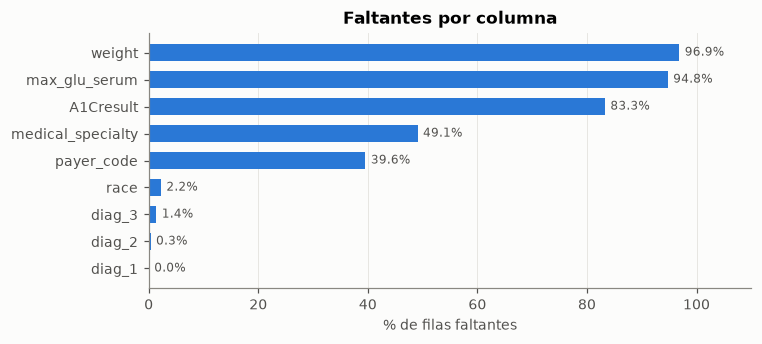

In [4]:
df_raw = df.copy()
# '?' es el marcador de faltante. En max_glu_serum/A1Cresult, 'None' (leído como NaN) significa "no se midió".
faltantes = pd.DataFrame({
    'NaN': df.isna().sum(),
    "'?'": (df == '?').sum(),
})
faltantes['total'] = faltantes.sum(axis=1)
faltantes['%'] = (faltantes['total'] / len(df) * 100).round(2)
faltantes = faltantes[faltantes['total'] > 0].sort_values('%', ascending=False)
display(faltantes)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(faltantes.index[::-1], faltantes['%'][::-1], color=C[0], height=0.6)
for y, v in enumerate(faltantes['%'][::-1]):
    ax.text(v + 1, y, f'{v:.1f}%', va='center', color='#52514e', fontsize=8)
ax.set_xlim(0, 110); ax.set_xlabel('% de filas faltantes'); ax.set_title('Faltantes por columna')
ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

- **`weight` (97 %)**, **`max_glu_serum` (95 %)** y **`A1Cresult` (83 %)** están casi vacías. En las dos de laboratorio el faltante *no es aleatorio*: significa “no se pidió el examen”, lo cual es información en sí mismo → se puede convertir en categoría `'NoMedido'` en vez de borrar.
- **`medical_specialty` (49 %)** y **`payer_code` (40 %)**: faltantes altos; se pueden mantener como categoría `'Desconocido'` o eliminar.
- **`race` (2 %)**, `diag_1/2/3` (<1.5 %): faltantes bajos, fáciles de manejar.

### 2.2 Faltantes “disfrazados” dentro de los códigos de ID

In [5]:
mapping_raw = (DATA / 'IDS_mapping.csv').read_text().strip().split('\n,\n')
mappings = {}
for bloque in mapping_raw:
    lineas = bloque.strip().splitlines()
    nombre = lineas[0].split(',')[0]
    tabla = pd.read_csv(pd.io.common.StringIO('\n'.join(lineas)), keep_default_na=False)  # si no, 'NULL' se lee como NaN
    mappings[nombre] = dict(zip(tabla.iloc[:, 0].astype(int), tabla.iloc[:, 1].astype(str).str.strip()))

NULOS = ['NULL', 'Not Available', 'Not Mapped', 'Unknown/Invalid']
for col, m in mappings.items():
    codigos_nulos = [k for k, v in m.items() if v in NULOS]
    n = df[col].isin(codigos_nulos).sum()
    print(f'{col:28s} códigos nulos {codigos_nulos} -> {n:6d} filas ({n/len(df)*100:.1f}%)')

admission_type_id            códigos nulos [5, 6, 8] ->  10396 filas (10.2%)
discharge_disposition_id     códigos nulos [18, 25, 26] ->   4680 filas (4.6%)
admission_source_id          códigos nulos [9, 15, 17, 20, 21] ->   7067 filas (6.9%)


Los códigos 5, 6, 8 (admission_type, ~10 %), 18, 25, 26 (discharge, ~5 %) y 9, 15, 17, 20, 21 (admission_source, ~7 %) significan *NULL / Not Available / Not Mapped*.
**No aparecen como faltantes** porque son números válidos. Si se tratan como numéricos (error típico en KNN), el modelo asume que `admission_type_id=6` está “más lejos” de 1 que 2, lo cual no tiene sentido.

### 2.3 Encuentros de pacientes fallecidos / hospicio

In [6]:
fallecidos = df['discharge_disposition_id'].isin([11, 19, 20, 21])
hospicio = df['discharge_disposition_id'].isin([13, 14])
print('Fallecidos:', fallecidos.sum(), '| readmitted de esos:', df.loc[fallecidos, 'readmitted'].value_counts().to_dict())
print('Hospicio  :', hospicio.sum())

Fallecidos: 1652 | readmitted de esos: {'NO': 1652}
Hospicio  : 771


Un paciente fallecido **no puede reingresar**: esas filas contaminan el objetivo (`NO` trivial). Se recomienda eliminarlas (y opcionalmente hospicio).

### 2.4 Varios encuentros por paciente (observaciones no independientes)

Encuentros: 101766 | Pacientes únicos: 71518
Pacientes con >1 encuentro: 16773 (23.5%)
Filas que pertenecen a pacientes repetidos: 46.2%
Máximo de encuentros de un paciente: 40


Filas duplicadas exactas: 0 | encounter_id repetidos: 0


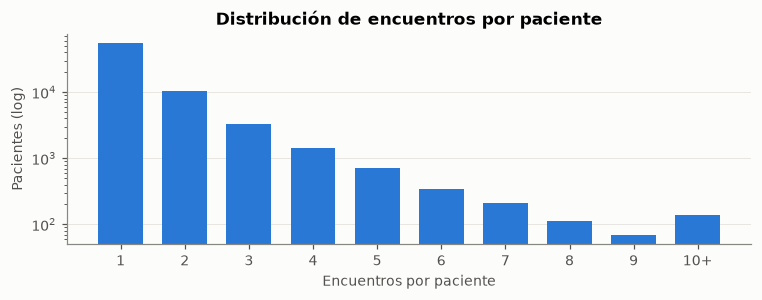

In [7]:
enc_por_pac = df['patient_nbr'].value_counts()
print('Encuentros:', len(df), '| Pacientes únicos:', enc_por_pac.size)
print('Pacientes con >1 encuentro:', (enc_por_pac > 1).sum(), f'({(enc_por_pac > 1).mean()*100:.1f}%)')
filas_rep = df['patient_nbr'].map(enc_por_pac).gt(1).mean() * 100
print(f'Filas que pertenecen a pacientes repetidos: {filas_rep:.1f}%')
print('Máximo de encuentros de un paciente:', enc_por_pac.max())
print('Filas duplicadas exactas:', df.duplicated().sum(), '| encounter_id repetidos:', df['encounter_id'].duplicated().sum())

fig, ax = plt.subplots(figsize=(7, 2.8))
vc = enc_por_pac.clip(upper=10).value_counts().sort_index()
ax.bar(vc.index.astype(str).str.replace('10', '10+'), vc.values, color=C[0], width=0.7)
ax.set_yscale('log'); ax.set_xlabel('Encuentros por paciente'); ax.set_ylabel('Pacientes (log)')
ax.set_title('Distribución de encuentros por paciente'); ax.grid(axis='x', visible=False)
plt.tight_layout(); plt.show()

23.5 % de los pacientes aparece más de una vez, y esos pacientes concentran **~46 % de las filas**. Consecuencias:
- **KNN:** si un split aleatorio pone encuentros del mismo paciente en train y test, el vecino más cercano será *el mismo paciente* → accuracy inflada (**fuga de información**). Usar `GroupShuffleSplit`/`GroupKFold` por `patient_nbr`, o quedarse con el **primer encuentro** de cada paciente (práctica del paper original).
- **Clustering:** un paciente con 40 encuentros crea una “mini-densidad” artificial.

### 2.5 Columnas constantes o casi constantes

In [8]:
MEDS = list(df.loc[:, 'metformin':'metformin-pioglitazone'].columns)
pct_moda = df.apply(lambda s: s.value_counts(normalize=True, dropna=False).iloc[0] * 100).sort_values(ascending=False)
casi_const = pct_moda[pct_moda > 99]
print('Columnas con >99% del mismo valor:')
display(casi_const.round(3).to_frame('% valor más frecuente'))

Columnas con >99% del mismo valor:


,% valor más frecuente
citoglipton,100.000
examide,100.000
metformin-pioglitazone,99.999
acetohexamide,99.999
glimepiride-pioglitazone,99.999
metformin-rosiglitazone,99.998
troglitazone,99.997
glipizide-metformin,99.987
tolbutamide,99.977
miglitol,99.963


`examide` y `citoglipton` son **constantes** (varianza 0). Otras 10 columnas de medicamentos tienen >99 % de `No`: aportan casi nada y, en one-hot, producen columnas casi vacías que **hacen singulares las covarianzas de la GMM**.

### 2.6 Otros valores problemáticos

In [9]:
print(df['gender'].value_counts().to_dict())
print('\nmedical_specialty: %d categorías' % df['medical_specialty'].nunique())
print('payer_code: %d categorías' % df['payer_code'].nunique())
for c in ['diag_1', 'diag_2', 'diag_3']:
    s = df[c]
    print(f"{c}: {s.nunique()} códigos | V-codes: {s.str.startswith('V').sum()} | E-codes: {s.str.startswith('E').sum()}")

{'Female': 54708, 'Male': 47055, 'Unknown/Invalid': 3}

medical_specialty: 73 categorías
payer_code: 18 categorías
diag_1: 717 códigos | V-codes: 1644 | E-codes: 1
diag_2: 749 códigos | V-codes: 1805 | E-codes: 731
diag_3: 790 códigos | V-codes: 3814 | E-codes: 1244


- `gender` tiene 3 filas `Unknown/Invalid` → eliminar.
- `diag_*` son **texto** (mezclan `250.83`, `V27`, `E909`): no se pueden usar como número. Hay que agruparlos en capítulos ICD-9 (sección 5.3).
- `medical_specialty` (73 categorías) y diagnósticos (~700+): **alta cardinalidad** → one-hot explota la dimensionalidad.

## 3. Variable objetivo: `readmitted`

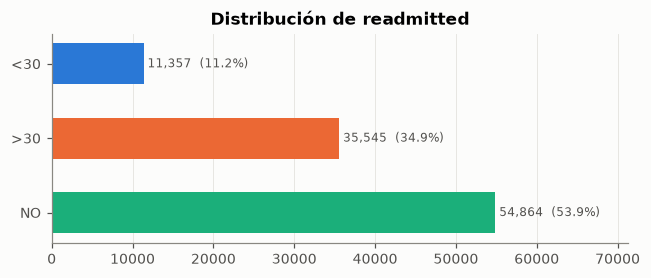

In [10]:
vc = df['readmitted'].value_counts().reindex(TARGET_ORDER)
fig, ax = plt.subplots(figsize=(6, 2.6))
ax.barh(vc.index[::-1], vc.values[::-1], color=[TARGET_COLORS[k] for k in vc.index[::-1]], height=0.55)
for y, (k, v) in enumerate(vc[::-1].items()):
    ax.text(v + 500, y, f'{v:,}  ({v/len(df)*100:.1f}%)', va='center', color='#52514e', fontsize=8)
ax.set_xlim(0, vc.max() * 1.3); ax.set_title('Distribución de readmitted'); ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

**Desbalance:** la clase de mayor interés clínico (`<30`) es solo **11 %**. Un KNN que siempre dice `NO` ya obtiene ~54 % de accuracy; para binario `<30` vs resto, 89 %.
→ Usar **F1 / recall / balanced accuracy / ROC-AUC**, no accuracy; considerar `weights='distance'`, submuestreo o ajuste del umbral.

## 4. Variables numéricas

In [11]:
NUM = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
desc = df[NUM].describe().T
desc['asimetría'] = df[NUM].skew()
desc['% ceros'] = (df[NUM] == 0).mean() * 100
q1, q3 = df[NUM].quantile(.25), df[NUM].quantile(.75)
iqr = q3 - q1
desc['% outliers IQR'] = (((df[NUM] < q1 - 1.5 * iqr) | (df[NUM] > q3 + 1.5 * iqr)).mean() * 100)
desc['n_valores'] = df[NUM].nunique()
display(desc.round(2))

,count,mean,std,min,25%,50%,75%,max,asimetría,% ceros,% outliers IQR,n_valores
time_in_hospital,101766.0,4.40,2.99,1.0,2.0,4.0,6.0,14.0,1.13,0.00,2.21,14
num_lab_procedures,101766.0,43.10,19.67,1.0,31.0,44.0,57.0,132.0,-0.24,0.00,0.14,118
num_procedures,101766.0,1.34,1.71,0.0,0.0,1.0,2.0,6.0,1.32,45.84,4.87,7
num_medications,101766.0,16.02,8.13,1.0,10.0,15.0,20.0,81.0,1.33,0.00,2.51,75
number_outpatient,101766.0,0.37,1.27,0.0,0.0,0.0,0.0,42.0,8.83,83.55,16.45,39
number_emergency,101766.0,0.20,0.93,0.0,0.0,0.0,0.0,76.0,22.86,88.81,11.19,33
number_inpatient,101766.0,0.64,1.26,0.0,0.0,0.0,1.0,21.0,3.61,66.46,6.93,21
number_diagnoses,101766.0,7.42,1.93,1.0,6.0,8.0,9.0,16.0,-0.88,0.00,0.28,16


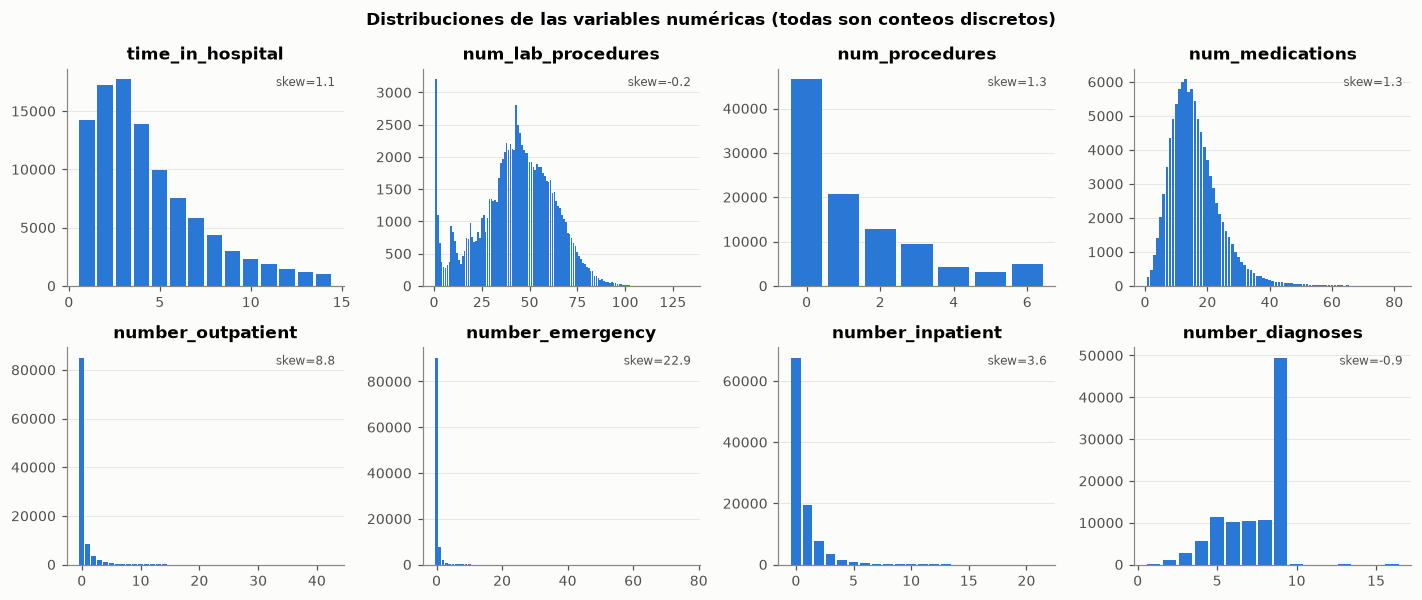

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5.5))
for ax, c in zip(axes.ravel(), NUM):
    vc = df[c].value_counts().sort_index()
    ax.bar(vc.index, vc.values, color=C[0], width=0.85)
    ax.set_title(c); ax.grid(axis='x', visible=False)
    ax.text(0.97, 0.92, f'skew={df[c].skew():.1f}', transform=ax.transAxes, ha='right', color='#52514e', fontsize=8)
fig.suptitle('Distribuciones de las variables numéricas (todas son conteos discretos)', fontweight='bold')
plt.tight_layout(); plt.show()

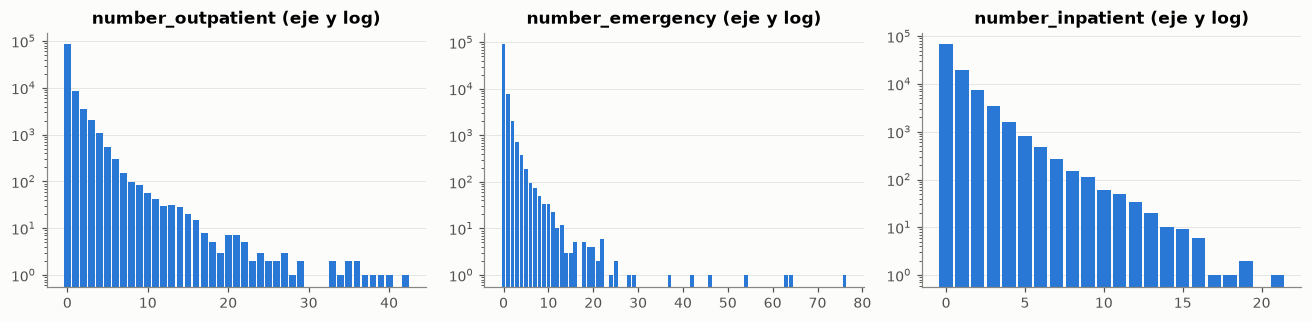

In [13]:
# Las tres de visitas previas: escala log para ver la cola
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, c in zip(axes, ['number_outpatient', 'number_emergency', 'number_inpatient']):
    vc = df[c].value_counts().sort_index()
    ax.bar(vc.index, vc.values, color=C[0], width=0.85)
    ax.set_yscale('log'); ax.set_title(c + ' (eje y log)'); ax.grid(axis='x', visible=False)
plt.tight_layout(); plt.show()

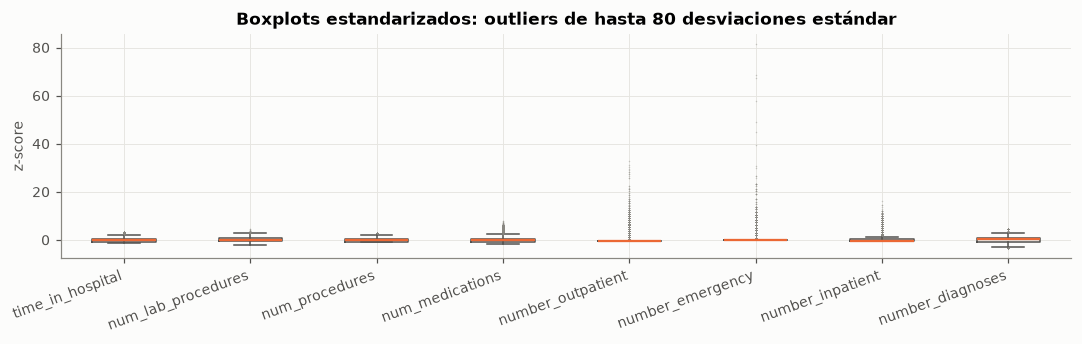

In [14]:
fig, ax = plt.subplots(figsize=(10, 3.2))
Z = (df[NUM] - df[NUM].mean()) / df[NUM].std()
ax.boxplot([Z[c] for c in NUM], widths=0.5, showfliers=True,
           flierprops=dict(marker='.', markersize=2, markerfacecolor=MUTED, markeredgecolor='none', alpha=.4),
           medianprops=dict(color=C[1], linewidth=1.5), boxprops=dict(color='#52514e'),
           whiskerprops=dict(color='#52514e'), capprops=dict(color='#52514e'))
ax.set_xticks(range(1, len(NUM) + 1), NUM, rotation=20, ha='right')
ax.set_ylabel('z-score'); ax.set_title('Boxplots estandarizados: outliers de hasta 80 desviaciones estándar')
plt.tight_layout(); plt.show()

**Hallazgos numéricos**
- Todas son **enteros discretos** con pocos valores posibles (7 a 132). No son continuas.
- `number_outpatient`, `number_emergency`, `number_inpatient` son **muy asimétricas** (skew 3.6–22.9) con **66–89 % ceros** y outliers extremos (`number_emergency` llega a 76 → ~80σ).
- `num_lab_procedures` y `number_diagnoses` son las únicas relativamente simétricas (`number_diagnoses` tiene un tope artificial en 9 — cambio de sistema de registro).
- **Escalas muy distintas** (0–6 vs 1–132): sin estandarizar, `num_lab_procedures` dominaría cualquier distancia euclídea.
- Transformación sugerida: `log1p` en las de visitas previas (y quizá `num_medications`) + `StandardScaler`/`RobustScaler`.

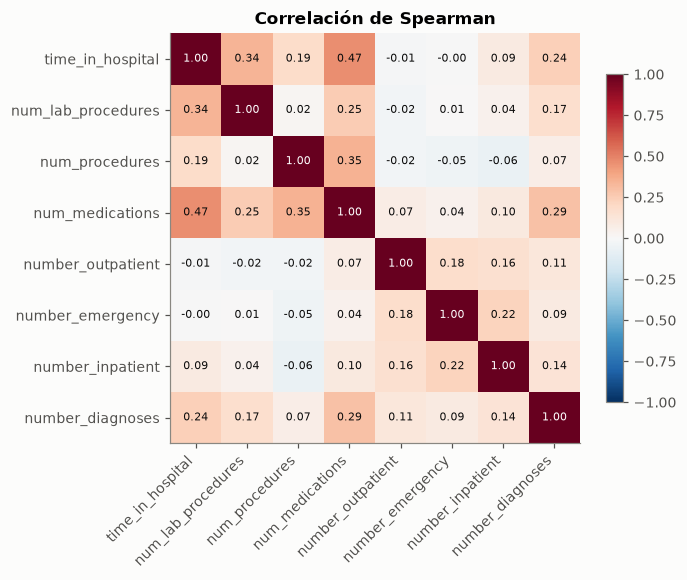

In [15]:
corr = df[NUM].corr(method='spearman')
fig, ax = plt.subplots(figsize=(6.5, 5.3))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(NUM)), NUM, rotation=45, ha='right'); ax.set_yticks(range(len(NUM)), NUM)
for i in range(len(NUM)):
    for j in range(len(NUM)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(corr.iloc[i, j]) > 0.5 else '#0b0b0b')
ax.grid(False); fig.colorbar(im, shrink=.8); ax.set_title('Correlación de Spearman')
plt.tight_layout(); plt.show()

Correlaciones **bajas-moderadas** (máx ≈ 0.47 entre `time_in_hospital` y `num_medications`). No hay redundancia fuerte, pero tampoco una estructura lineal marcada: es una primera señal de que los grupos naturales no serán muy separados.

## 5. Variables categóricas

### 5.1 Demografía

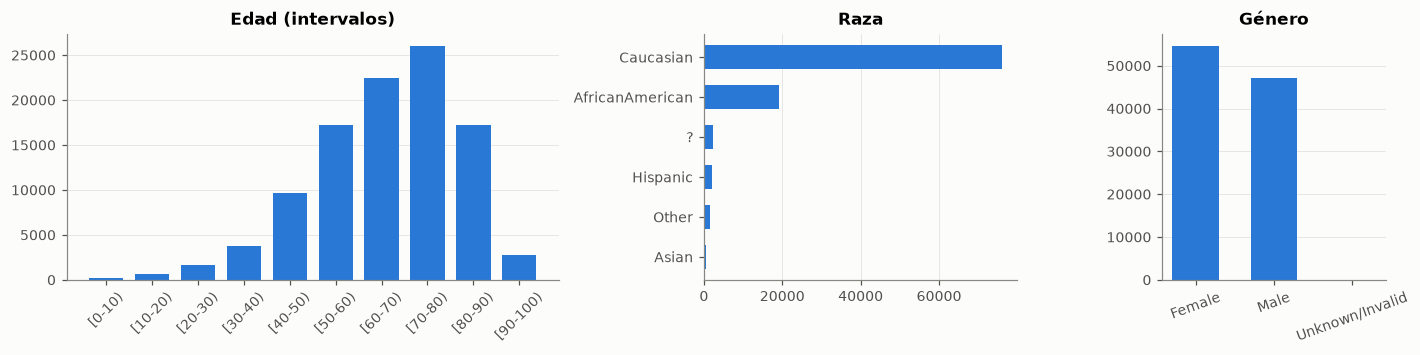

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.3), gridspec_kw={'width_ratios': [2.2, 1.4, 1]})
age = df['age'].value_counts().sort_index()
axes[0].bar(age.index, age.values, color=C[0], width=0.75); axes[0].set_title('Edad (intervalos)')
axes[0].tick_params(axis='x', rotation=45)
race = df['race'].value_counts()
axes[1].barh(race.index[::-1], race.values[::-1], color=C[0], height=0.6); axes[1].set_title('Raza')
g = df['gender'].value_counts()
axes[2].bar(g.index, g.values, color=C[0], width=0.6); axes[2].set_title('Género'); axes[2].tick_params(axis='x', rotation=20)
for a in axes: a.grid(axis='x' if a is not axes[1] else 'y', visible=False)
plt.tight_layout(); plt.show()

Población **mayor** (70 % tiene 60+ años) y **mayoritariamente caucásica** (75 %). `age` debe codificarse como **ordinal** (punto medio del intervalo), no one-hot.

### 5.2 Admisión, alta y administrativas

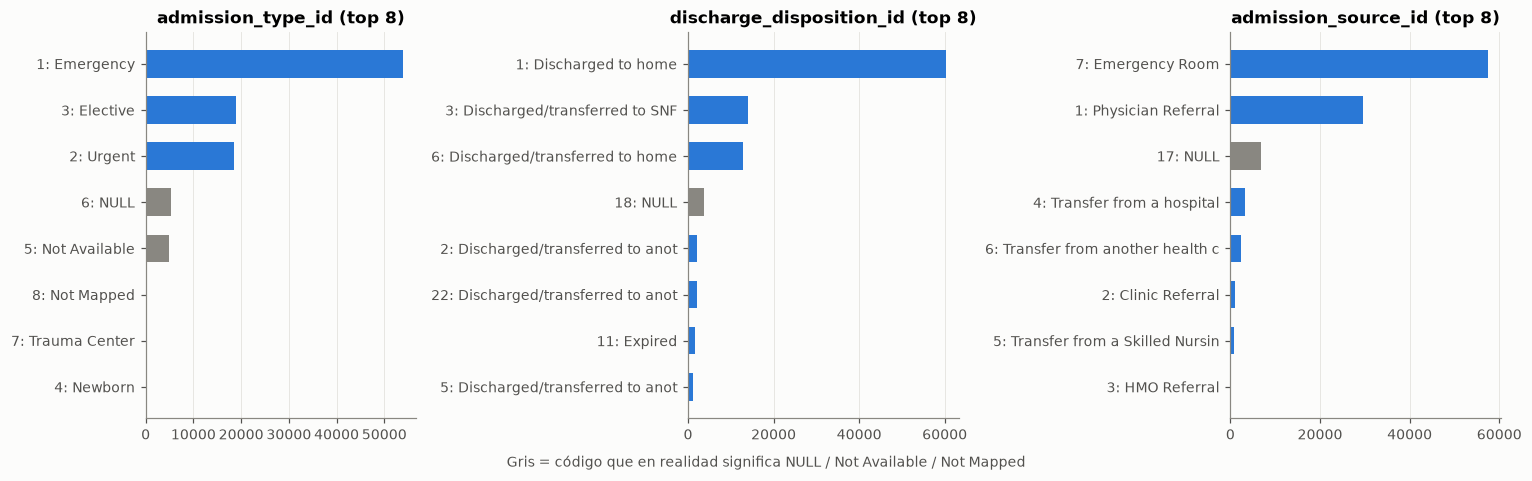

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, col in zip(axes, mappings):
    vc = df[col].value_counts().head(8)
    desc = [mappings[col].get(k, '?') for k in vc.index]
    etiquetas = [f'{k}: {d[:30]}' for k, d in zip(vc.index, desc)]
    colores = [MUTED if d in NULOS else C[0] for d in desc]
    ax.barh(etiquetas[::-1], vc.values[::-1], color=colores[::-1], height=0.6)
    ax.set_title(col + ' (top 8)'); ax.grid(axis='y', visible=False)
fig.text(0.5, -0.02, 'Gris = código que en realidad significa NULL / Not Available / Not Mapped', ha='center', color='#52514e')
plt.tight_layout(); plt.show()

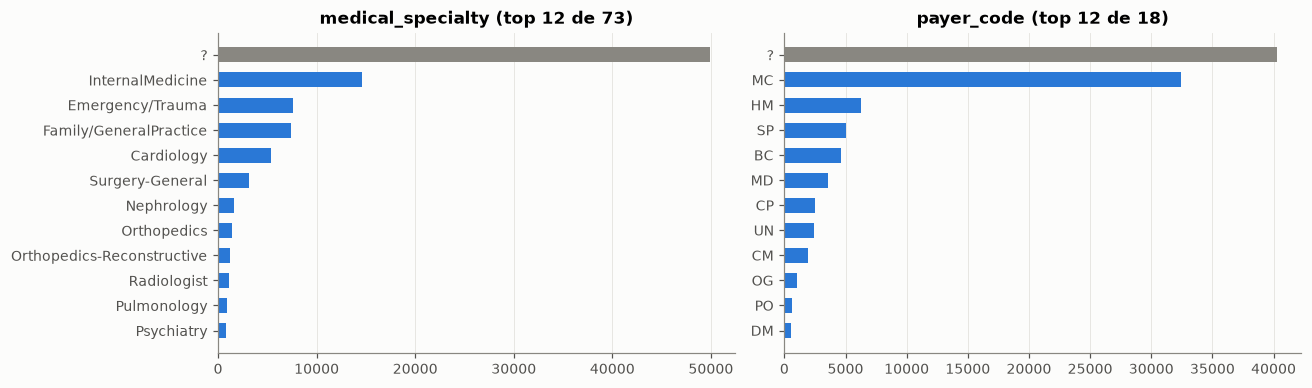

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, col in zip(axes, ['medical_specialty', 'payer_code']):
    vc = df[col].value_counts().head(12)
    ax.barh(vc.index[::-1], vc.values[::-1], color=[MUTED if i == '?' else C[0] for i in vc.index[::-1]], height=0.6)
    ax.set_title(f'{col} (top 12 de {df[col].nunique()})'); ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

### 5.3 Diagnósticos agrupados por capítulo ICD-9

,diag_1,diag_2,diag_3
Circulatorio,29.9,31.3,29.8
Otros,17.9,26.1,28.7
Respiratorio,14.2,10.7,7.2
Digestivo,9.3,4.1,3.9
Diabetes,8.6,12.6,16.9
Lesiones,6.9,2.4,1.9
Genitourinario,5.0,8.2,6.6
Musculoesquelético,4.9,1.7,1.9
Neoplasias,3.4,2.5,1.8
Desconocido,0.0,0.4,1.4


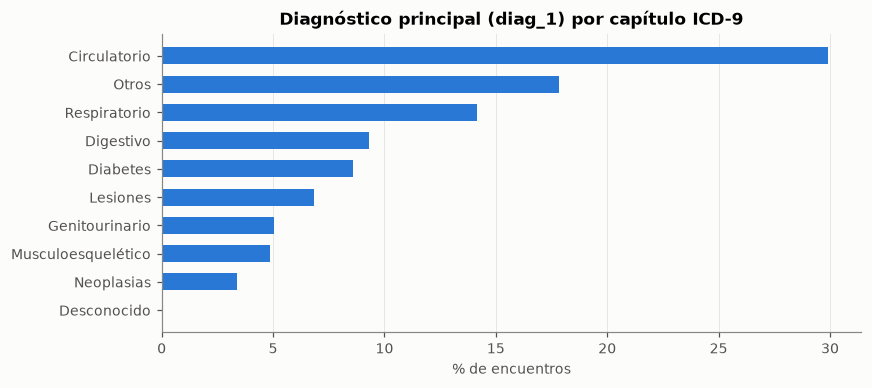

In [19]:
def icd9_grupo(code):
    if code == '?' or pd.isna(code):
        return 'Desconocido'
    if code.startswith(('V', 'E')):
        return 'Otros'
    x = float(code)
    if 390 <= x <= 459 or int(x) == 785: return 'Circulatorio'
    if 460 <= x <= 519 or int(x) == 786: return 'Respiratorio'
    if 520 <= x <= 579 or int(x) == 787: return 'Digestivo'
    if int(x) == 250:                    return 'Diabetes'
    if 800 <= x <= 999:                  return 'Lesiones'
    if 710 <= x <= 739:                  return 'Musculoesquelético'
    if 580 <= x <= 629 or int(x) == 788: return 'Genitourinario'
    if 140 <= x <= 239:                  return 'Neoplasias'
    return 'Otros'

for c in ['diag_1', 'diag_2', 'diag_3']:
    df[c + '_grupo'] = df[c].map(icd9_grupo)

tab = pd.concat({c: df[c + '_grupo'].value_counts(normalize=True) * 100 for c in ['diag_1', 'diag_2', 'diag_3']}, axis=1)
tab = tab.sort_values('diag_1', ascending=False)
display(tab.round(1))
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(tab.index[::-1], tab['diag_1'][::-1], color=C[0], height=0.6)
ax.set_xlabel('% de encuentros'); ax.set_title('Diagnóstico principal (diag_1) por capítulo ICD-9'); ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

Agrupar reduce ~717 códigos a **10 categorías** interpretables. El diagnóstico principal más frecuente es **circulatorio** (30 %); la diabetes como diagnóstico principal es solo ~9 %.

### 5.4 Laboratorio y medicamentos

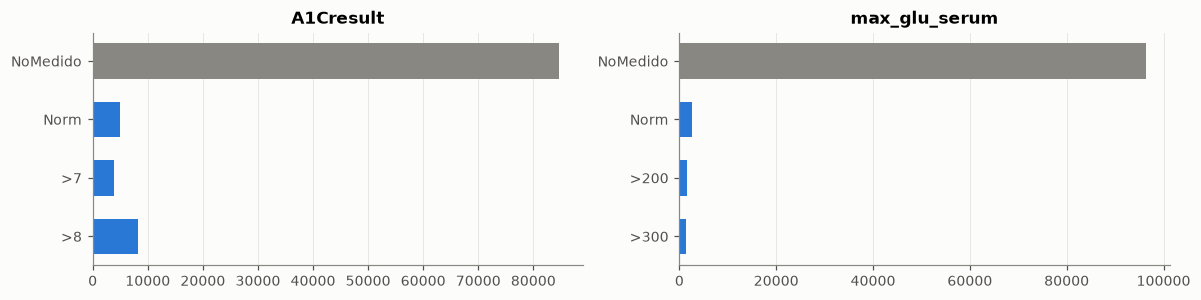

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 2.8))
for ax, col, orden in zip(axes, ['A1Cresult', 'max_glu_serum'], [['Norm', '>7', '>8'], ['Norm', '>200', '>300']]):
    vc = df[col].fillna('NoMedido').value_counts().reindex(['NoMedido'] + orden)
    ax.barh(vc.index[::-1], vc.values[::-1], color=[MUTED if i == 'NoMedido' else C[0] for i in vc.index[::-1]], height=0.6)
    ax.set_title(col); ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

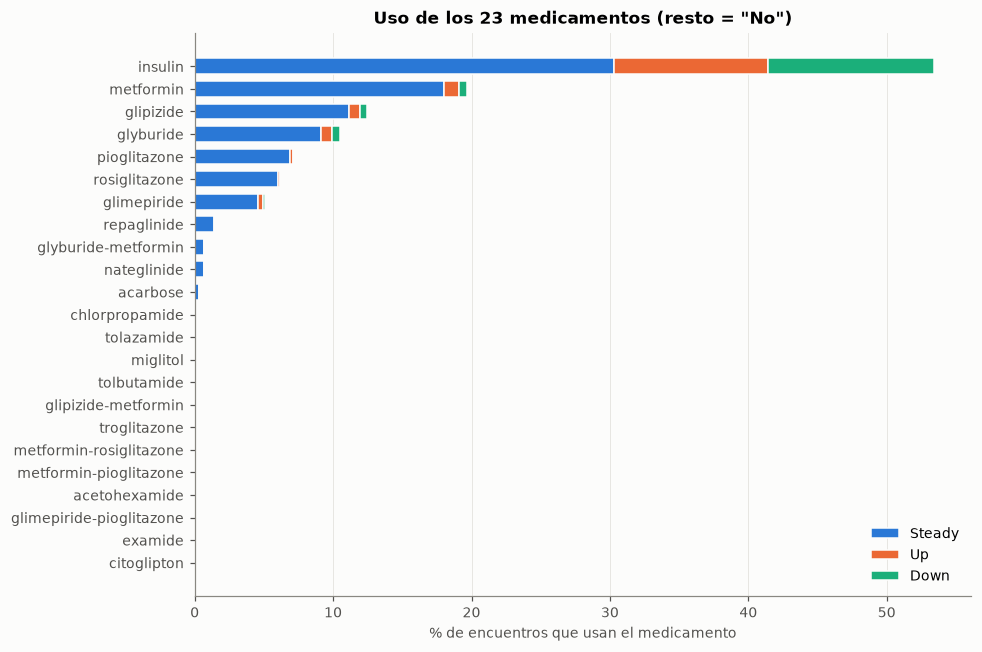

change          {'No': 54755, 'Ch': 47011}
diabetesMed    {'Yes': 78363, 'No': 23403}
dtype: object


In [21]:
uso = pd.DataFrame({m: df[m].value_counts(normalize=True) * 100 for m in MEDS}).T.fillna(0)[['No', 'Steady', 'Up', 'Down']]
uso = uso.sort_values('No')
fig, ax = plt.subplots(figsize=(9, 6))
izq = np.zeros(len(uso))
for k, col in zip(['Steady', 'Up', 'Down'], C):
    ax.barh(uso.index, uso[k], left=izq, color=col, label=k, height=0.7, edgecolor='#fcfcfb', linewidth=1)
    izq += uso[k].values
ax.set_xlabel('% de encuentros que usan el medicamento'); ax.legend(frameon=False, loc='lower right')
ax.set_title('Uso de los 23 medicamentos (resto = "No")'); ax.grid(axis='y', visible=False); ax.invert_yaxis()
plt.tight_layout(); plt.show()
print(df[['change', 'diabetesMed']].apply(lambda s: s.value_counts().to_dict()))

Solo **insulina** (53 %) y **metformina** (20 %) se usan de forma extendida; seguidos de glipizida/gliburida/pioglitazona/rosiglitazona/glimepirida (5–12 %). El resto es ruido. Una simplificación útil: `n_meds_activos` (cuántos ≠ `No`) y `n_cambios` (cuántos `Up`/`Down`).

## 6. Relación con `readmitted`

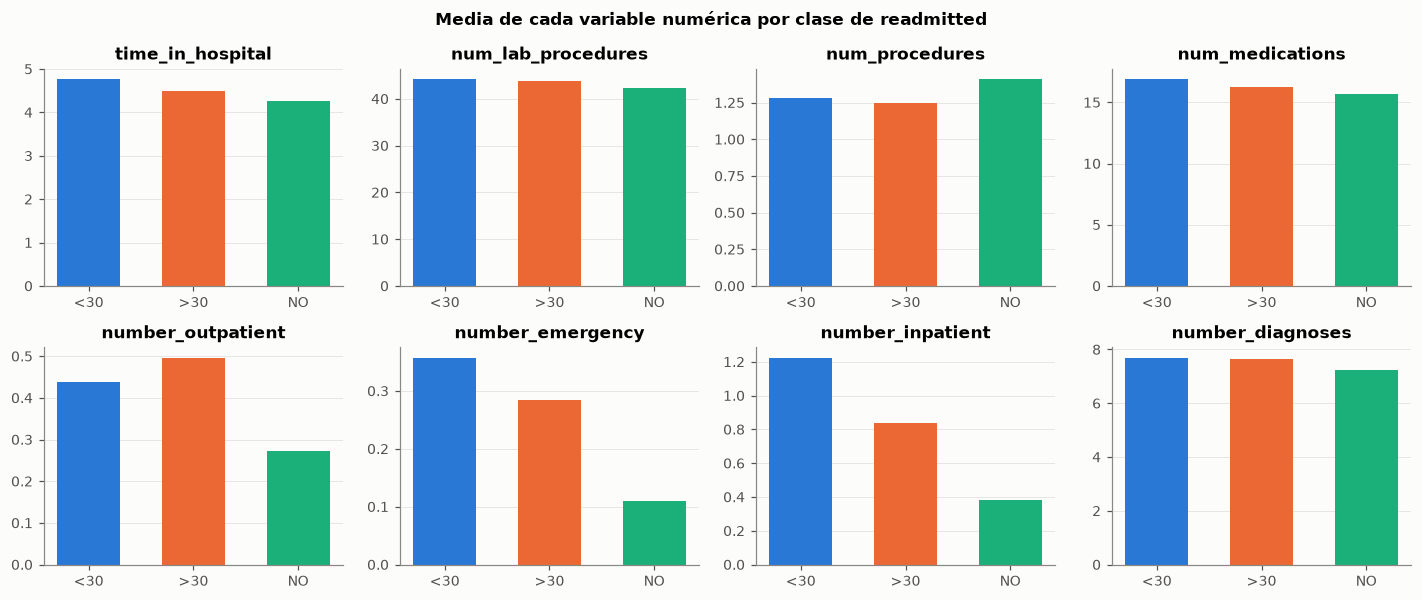

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5.5))
for ax, c in zip(axes.ravel(), NUM):
    medias = df.groupby('readmitted')[c].mean().reindex(TARGET_ORDER)
    ax.bar(medias.index, medias.values, color=[TARGET_COLORS[k] for k in medias.index], width=0.6)
    ax.set_title(c); ax.grid(axis='x', visible=False)
fig.suptitle('Media de cada variable numérica por clase de readmitted', fontweight='bold')
plt.tight_layout(); plt.show()

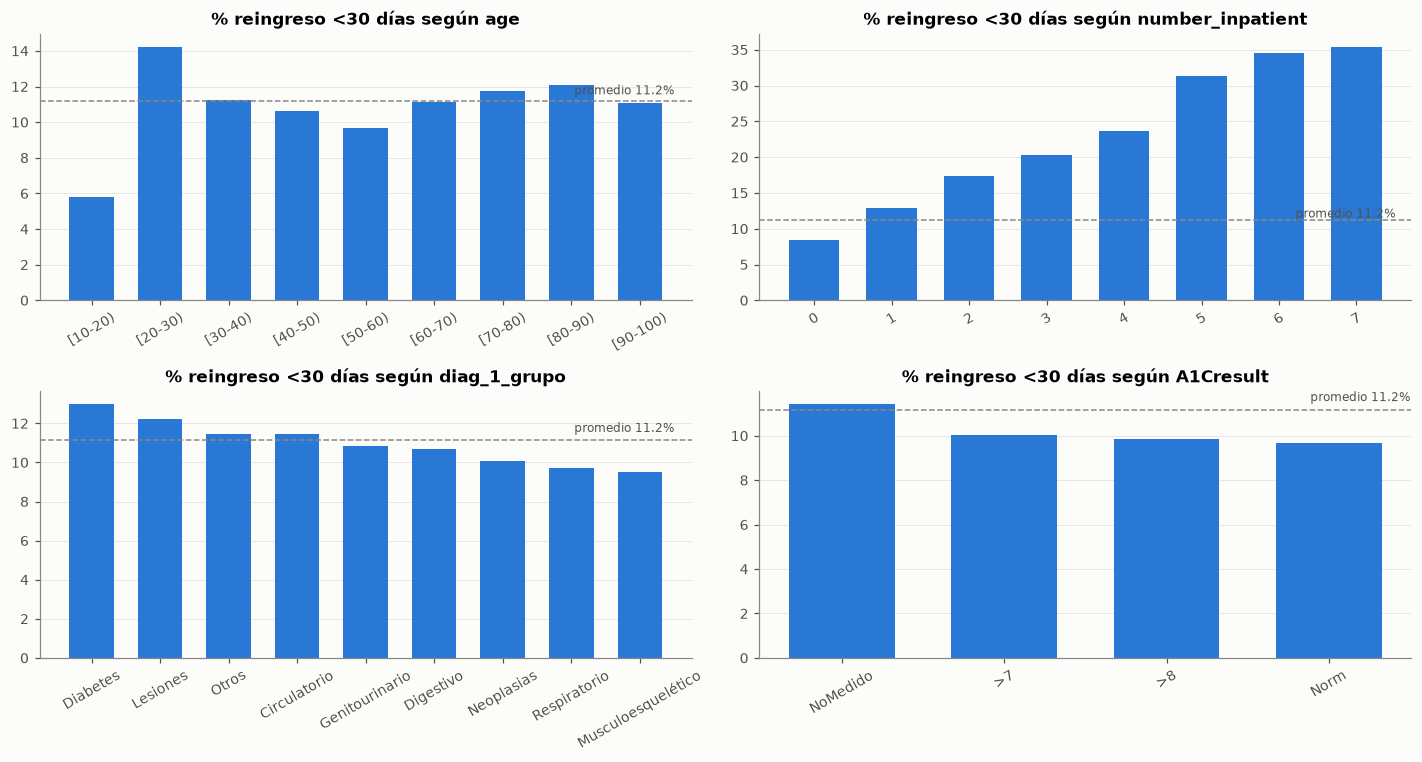

In [23]:
base = (df['readmitted'] == '<30').mean() * 100
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
paneles = [('age', sorted(df['age'].unique()), None), ('number_inpatient', list(range(0, 10)), None),
           ('diag_1_grupo', None, None), ('A1Cresult', None, None)]
for ax, (col, orden, top) in zip(axes.ravel(), paneles):
    s = df[col].fillna('NoMedido') if col == 'A1Cresult' else df[col]
    tmp = df.assign(**{col: s})
    t = tmp.groupby(col)['readmitted'].apply(lambda x: (x == '<30').mean() * 100)
    n = tmp[col].value_counts(); t = t[n[n >= 200].index]
    t = t.reindex([o for o in orden if o in t.index]) if orden else t.sort_values(ascending=False)
    ax.bar(t.index.astype(str), t.values, color=TARGET_COLORS['<30'], width=0.65)
    ax.axhline(base, color=MUTED, linestyle='--', linewidth=1)
    ax.text(len(t) - 0.5, base + 0.4, f'promedio {base:.1f}%', ha='right', color='#52514e', fontsize=8)
    ax.set_title(f'% reingreso <30 días según {col}'); ax.tick_params(axis='x', rotation=30); ax.grid(axis='x', visible=False)
plt.tight_layout(); plt.show()

- **`number_inpatient` es la variable más informativa**: la tasa de reingreso `<30` pasa de ~8 % (0 hospitalizaciones previas) a >30 % con 5+ previas. Lo mismo, en menor medida, `number_emergency`.
- El resto de las numéricas cambia poco entre clases → las clases **se solapan mucho** en el espacio de features. Es esperable que KNN tenga un rendimiento modesto (AUC típica en este dataset ≈ 0.6–0.7).

## 7. Diagnóstico de estructura para clustering

In [24]:
# Las 8 numéricas son discretas: ¿cuántos puntos idénticos hay?
dup_num = df[NUM].duplicated().mean() * 100
print(f'Filas cuyo vector numérico está repetido: {dup_num:.1f}%')
print('Combinaciones únicas:', len(df[NUM].drop_duplicates()), 'de', len(df))

Filas cuyo vector numérico está repetido: 9.8%
Combinaciones únicas: 91795 de 101766


Varianza explicada acumulada: [0.25 0.44 0.56 0.67 0.77 0.86 0.94 1.  ]


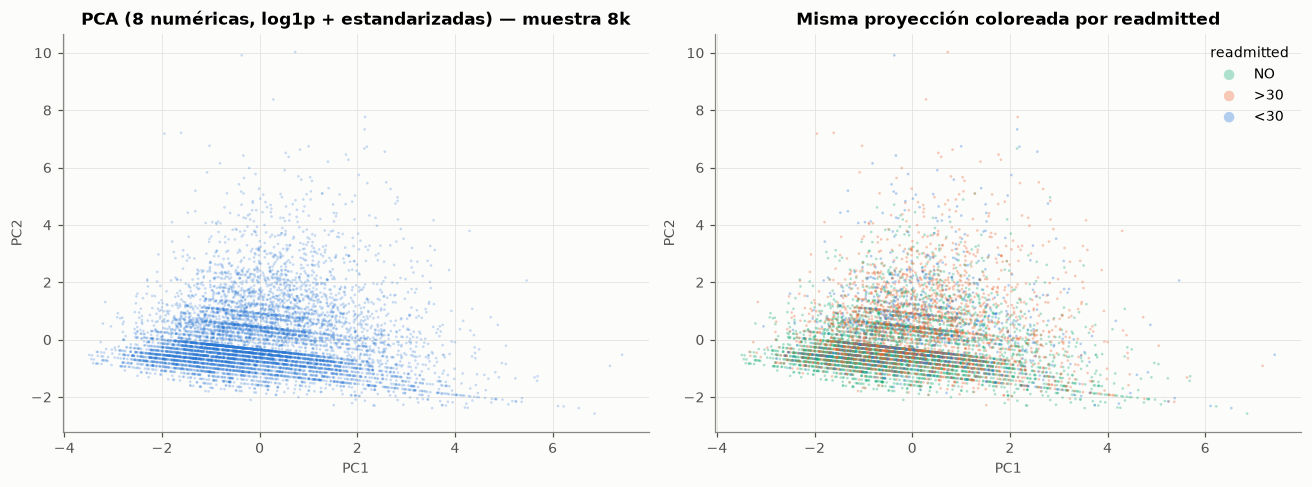

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[NUM].copy()
for c in ['number_outpatient', 'number_emergency', 'number_inpatient']:
    X[c] = np.log1p(X[c])
Xs = StandardScaler().fit_transform(X)
pca = PCA().fit(Xs)
print('Varianza explicada acumulada:', np.round(np.cumsum(pca.explained_variance_ratio_), 2))

rng = np.random.default_rng(0)
idx = rng.choice(len(df), 8000, replace=False)
P = pca.transform(Xs[idx])[:, :2]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(P[:, 0], P[:, 1], s=3, alpha=.25, color=C[0], edgecolors='none')
axes[0].set_title('PCA (8 numéricas, log1p + estandarizadas) — muestra 8k')
for k in TARGET_ORDER[::-1]:
    m = df['readmitted'].values[idx] == k
    axes[1].scatter(P[m, 0], P[m, 1], s=3, alpha=.35, color=TARGET_COLORS[k], label=k, edgecolors='none')
axes[1].legend(markerscale=4, frameon=False, title='readmitted'); axes[1].set_title('Misma proyección coloreada por readmitted')
for a in axes: a.set_xlabel('PC1'); a.set_ylabel('PC2')
plt.tight_layout(); plt.show()

- Hacen falta ~6 de 8 componentes para explicar el 85 % de la varianza → la información está **repartida**, no hay pocas direcciones dominantes.
- La proyección es **una nube continua** sin grupos separados visibles, y las 3 clases de `readmitted` están completamente mezcladas. Las franjas/“rayas” son efecto de las variables discretas.

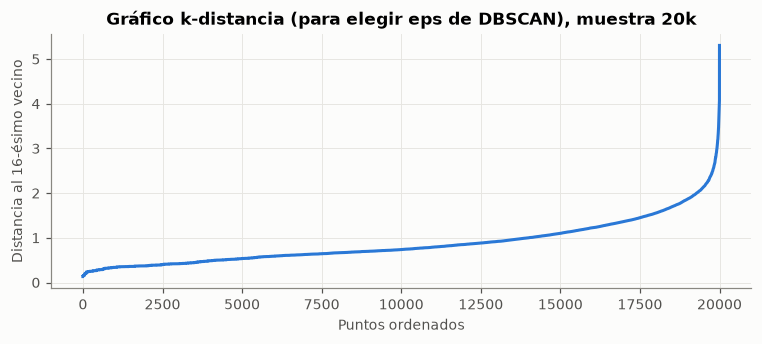

Percentiles de la k-distancia: {50: np.float64(0.74), 90: np.float64(1.55), 95: np.float64(1.87), 99: np.float64(2.53)}


In [26]:
from sklearn.neighbors import NearestNeighbors
k = 16  # regla práctica: min_samples ≈ 2·dim
sub = Xs[rng.choice(len(Xs), 20000, replace=False)]
dist, _ = NearestNeighbors(n_neighbors=k).fit(sub).kneighbors(sub)
kd = np.sort(dist[:, -1])
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(kd, color=C[0], linewidth=2)
ax.set_xlabel('Puntos ordenados'); ax.set_ylabel(f'Distancia al {k}-ésimo vecino')
ax.set_title('Gráfico k-distancia (para elegir eps de DBSCAN), muestra 20k')
plt.tight_layout(); plt.show()
print('Percentiles de la k-distancia:', dict(zip([50, 90, 95, 99], np.percentile(kd, [50, 90, 95, 99]).round(2))))

La curva k-distancia **sube de forma gradual** durante ~95 % de los puntos y solo tiene un codo marcado al final (≈ 2–2.5). Eso indica una densidad bastante continua: con `eps` en el codo, DBSCAN probablemente dará **un gran cluster + unos pocos % de ruido** (pacientes con muchas visitas previas o muchos procedimientos). Para encontrar subgrupos habrá que bajar `eps` (≈ 1–1.5) y/o trabajar con un subconjunto de variables.

## 8. Resumen de problemas detectados

| # | Problema | Evidencia | Tratamiento sugerido |
|---|---|---|---|
| 1 | Faltantes codificados como `'?'` | `weight` 97 %, `medical_specialty` 49 %, `payer_code` 40 %, `race` 2 % | `replace('?', NaN)`; eliminar `weight`; categoría `Desconocido` para el resto |
| 2 | “No medido” en laboratorio | `max_glu_serum` 95 %, `A1Cresult` 83 % | Categoría `NoMedido` (es informativa) |
| 3 | Faltantes disfrazados en códigos ID | ~10 % de admission_type, ~7 % de admission_source y ~5 % de discharge son NULL/Not Mapped | Mapear a `Desconocido`; tratar IDs como **categóricas** |
| 4 | IDs numéricos que son categóricos | `admission_type_id` etc. son int64 | Agrupar + one-hot (nunca como distancia numérica) |
| 5 | Pacientes fallecidos/hospicio | 1 652 fallecidos (+771 hospicio) con `readmitted = NO` forzado | Eliminar |
| 6 | Observaciones no independientes | 71 518 pacientes en 101 766 filas; ~46 % de las filas son de pacientes repetidos | Primer encuentro por paciente o split por grupo |
| 7 | Columnas constantes/casi constantes | `examide`, `citoglipton` constantes; 10 meds >99 % `No` | Eliminar; resumir meds en conteos |
| 8 | Alta cardinalidad | diag_* ~700–800 códigos, specialty 73 | Agrupar ICD-9 en capítulos; top-N specialty + `Otra` |
| 9 | Variables discretas y asimétricas con outliers extremos | skew hasta 22.9, 66–89 % ceros | `log1p` + escalado (Standard/Robust) |
| 10 | Escalas distintas | rango 0–6 vs 1–132 | Estandarizar **siempre** antes de distancias |
| 11 | Desbalance del objetivo | `<30` = 11 % | Métricas balanceadas, estratificación |
| 12 | Clases muy solapadas / sin clusters evidentes | PCA, k-distancia | Expectativas realistas; seleccionar variables |
| 13 | `gender` inválido | 3 filas | Eliminar |

### Implicaciones por algoritmo

**KNN (supervisado, predice `readmitted`)**
- Basado en distancias → **estandarizar** es obligatorio; one-hot de categóricas con cuidado (muchas dummies diluyen el peso de las numéricas). Alternativa: distancia de Gower o limitarse a numéricas + pocas categóricas.
- **Fuga por paciente**: dividir por `patient_nbr` (`GroupKFold`) o deduplicar.
- **Desbalance**: evaluar con F1-macro / balanced accuracy / AUC; probar `weights='distance'`.
- 100k filas × dimensión alta → predicción lenta; usar `algorithm='ball_tree'`/`kd_tree` o PCA previo.

**DBSCAN (no supervisado)**
- Maldición de la dimensionalidad: con decenas de dummies, las distancias se vuelven casi iguales y `eps` pierde sentido → trabajar con **pocas variables numéricas escaladas** (o PCA 2–5 componentes).
- Datos **discretos** → ~10 % de los puntos son copias exactas de otro en el espacio numérico (ver sección 7), lo que crea “densidades” artificiales; se puede añadir *jitter* mínimo o deduplicar con pesos (`sample_weight`).
- Memoria/tiempo: DBSCAN sobre 100k puntos es costoso; usar muestra o `algorithm='ball_tree'`.
- Elegir `eps` con el gráfico k-distancia; los outliers (pacientes con muchas visitas) saldrán como ruido (-1), lo cual puede ser un hallazgo en sí.

**Mezcla Gaussiana (no supervisado)**
- Supone componentes gaussianas continuas: las variables son **conteos discretos con muchos ceros** → aplicar `log1p` y escalar; aun así el ajuste será aproximado.
- One-hot / columnas casi constantes → **covarianzas singulares**: usar solo numéricas (o PCA), `covariance_type='diag'` o subir `reg_covar`.
- Elegir número de componentes con **BIC/AIC**; varias inicializaciones (`n_init`).

**Para validar el clustering** (DBSCAN y GMM): silhouette / Davies-Bouldin, y luego cruzar los clusters con `readmitted` para ver si tienen sentido clínico.

## 9. Limpieza propuesta y exportación

In [27]:
def limpiar(df_raw):
    d = df_raw.copy().replace('?', np.nan)
    # 1. filas inválidas
    d = d[d['gender'] != 'Unknown/Invalid']
    d = d[~d['discharge_disposition_id'].isin([11, 13, 14, 19, 20, 21])]   # fallecidos y hospicio
    # 2. un encuentro por paciente (el primero)
    d = d.sort_values('encounter_id').drop_duplicates('patient_nbr', keep='first')
    # 3. columnas inútiles
    d = d.drop(columns=['weight', 'payer_code', 'examide', 'citoglipton', 'encounter_id'])
    # 4. faltantes informativos
    d['max_glu_serum'] = d['max_glu_serum'].fillna('NoMedido')
    d['A1Cresult'] = d['A1Cresult'].fillna('NoMedido')
    d['race'] = d['race'].fillna('Desconocido')
    d['medical_specialty'] = d['medical_specialty'].fillna('Desconocido')
    top_spec = d['medical_specialty'].value_counts().head(11).index   # 'Desconocido' + top 10
    d['medical_specialty'] = d['medical_specialty'].where(d['medical_specialty'].isin(top_spec), 'Otra')
    # 5. IDs -> categorías legibles, con nulos disfrazados -> 'Desconocido'
    for col, m in mappings.items():
        d[col] = d[col].map(m).replace({v: 'Desconocido' for v in NULOS}).fillna('Desconocido')
    # 6. edad ordinal (punto medio del intervalo)
    d['age_num'] = d['age'].str.extract(r'\[(\d+)-').astype(int)[0] + 5
    # 7. diagnósticos agrupados
    for c in ['diag_1', 'diag_2', 'diag_3']:
        d[c] = d[c].map(icd9_grupo)
    # 8. resumen de medicamentos
    meds = [m for m in MEDS if m in d.columns]
    d['n_meds_activos'] = (d[meds] != 'No').sum(axis=1)
    d['n_cambios_meds'] = d[meds].isin(['Up', 'Down']).sum(axis=1)
    raros = [m for m in meds if (d[m] == 'No').mean() > 0.99]
    d = d.drop(columns=raros)
    # 9. versiones log de conteos asimétricos
    for c in ['number_outpatient', 'number_emergency', 'number_inpatient']:
        d[c + '_log'] = np.log1p(d[c])
    d['readmitted_30'] = (d['readmitted'] == '<30').astype(int)
    return d.drop(columns=[c for c in d.columns if c.endswith('_grupo')])

clean = limpiar(df_raw)
print('Original:', df_raw.shape, '-> Limpio:', clean.shape)
print('Faltantes restantes:', int(clean.isna().sum().sum()))
print(clean['readmitted'].value_counts(normalize=True).round(3).to_dict())
display(clean.head())
clean.to_csv(DATA / 'diabetic_clean.csv', index=False)
print('Guardado en', DATA / 'diabetic_clean.csv')

Original: (101766, 50) -> Limpio: (69987, 39)
Faltantes restantes: 0
{'NO': 0.593, '>30': 0.318, '<30': 0.09}


,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,insulin,change,diabetesMed,readmitted,age_num,n_meds_activos,n_cambios_meds,number_outpatient_log,number_emergency_log,number_inpatient_log,readmitted_30
8,48330783,Caucasian,Female,[80-90),Urgent,Discharged to home,Transfer from a hospital,13,Desconocido,68,2,28,0,0,0,Circulatorio,Circulatorio,Otros,8,NoMedido,NoMedido,No,No,No,Steady,No,No,No,Steady,Ch,Yes,NO,85,2,0,0.0,0.0,0.0,0
9,63555939,Caucasian,Female,[90-100),Elective,Discharged/transferred to SNF,Transfer from a hospital,12,InternalMedicine,33,3,18,0,0,0,Circulatorio,Neoplasias,Respiratorio,8,NoMedido,NoMedido,No,No,No,No,No,No,Steady,Steady,Ch,Yes,NO,95,2,0,0.0,0.0,0.0,0
4,42519267,Caucasian,Male,[40-50),Emergency,Discharged to home,Emergency Room,1,Desconocido,51,0,8,0,0,0,Neoplasias,Neoplasias,Diabetes,5,NoMedido,NoMedido,No,No,No,Steady,No,No,No,Steady,Ch,Yes,NO,45,2,0,0.0,0.0,0.0,0
10,89869032,AfricanAmerican,Female,[40-50),Emergency,Discharged to home,Emergency Room,9,Desconocido,47,2,17,0,0,0,Diabetes,Circulatorio,Lesiones,9,NoMedido,NoMedido,No,No,No,No,No,No,No,Steady,No,Yes,>30,45,1,0,0.0,0.0,0.0,0
5,82637451,Caucasian,Male,[50-60),Urgent,Discharged to home,Clinic Referral,3,Desconocido,31,6,16,0,0,0,Circulatorio,Circulatorio,Diabetes,9,NoMedido,NoMedido,No,No,No,No,No,No,No,Steady,No,Yes,>30,55,1,0,0.0,0.0,0.0,0


Guardado en C:\Users\camilo\Desktop\ML lunes\Data\diabetic_clean.csv


**Qué NO hace esta limpieza (a propósito, porque depende del modelo):** escalado, one-hot y selección final de variables. Esos pasos deben ir **dentro de un `Pipeline`** y ajustarse solo con el set de entrenamiento (para KNN), o con el subconjunto de variables que se decida para DBSCAN/GMM.

Sugerencia de features para empezar con clustering (DBSCAN/GMM): `time_in_hospital`, `num_lab_procedures`, `num_procedures`, `num_medications`, `number_diagnoses`, `number_outpatient_log`, `number_emergency_log`, `number_inpatient_log`, `age_num`, `n_meds_activos` — todas escaladas.